<a href="https://colab.research.google.com/github/amankiitg/5DParallel/blob/main/DeepSpeed_Pipeline_Parallelism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DeepSpeed Pipeline Parallelism: Hands-On with 4× A100 GPUs

**Environment**: RunPod · 4× A100-80GB · DeepSpeed + PyTorch

We'll train a **1.5B parameter GPT-2 model** and compare:

| Experiment | GPUs | Strategy | What We Measure |
|-----------|------|----------|----------------|
| **Baseline** | 1 GPU | No parallelism | Memory ceiling, throughput floor |
| **Pipeline Parallel** | 4 GPUs | DeepSpeed `PipelineModule` (4 stages) | Memory savings, throughput gain |
| **Microbatch Scaling** | 4 GPUs | PP with m=4,8,16,32 | Bubble fraction effect |

**Key Question**: How much memory does PP save, and how does microbatch count affect throughput?

---

## How DeepSpeed Pipeline Parallelism Works

```
GPU 0 (Stage 0)     GPU 1 (Stage 1)     GPU 2 (Stage 2)     GPU 3 (Stage 3)
┌──────────────┐   ┌──────────────┐   ┌──────────────┐   ┌──────────────┐
│ Embedding +  │──→│ Transformer  │──→│ Transformer  │──→│ Transformer  │
│ Layers 0-11  │   │ Layers 12-23 │   │ Layers 24-35 │   │ Layers 36-47 │
│              │   │              │   │              │   │ + LM Head    │
└──────────────┘   └──────────────┘   └──────────────┘   └──────────────┘
     send act→          send act→          send act→
     ←recv grad         ←recv grad         ←recv grad
```

DeepSpeed uses the **1F1B (PipeDream Flush)** schedule internally:
- Warmup forward passes fill the pipeline
- Steady state alternates 1 backward + 1 forward
- Cooldown drains remaining backward passes
- Peak activation memory = **n** (pipeline depth), not m (microbatches)

## 0. Environment Setup

In [ ]:
# Verify GPU setup
!nvidia-smi --query-gpu=index,name,memory.total,memory.free --format=csv,noheader
print()

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.version.cuda}")
print(f"GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  [{i}] {torch.cuda.get_device_name(i)} — {torch.cuda.get_device_properties(i).total_mem / 1e9:.1f} GB")

0, NVIDIA A100-SXM4-80GB, 81920 MiB, 81149 MiB
1, NVIDIA A100-SXM4-80GB, 81920 MiB, 81149 MiB
2, NVIDIA A100-SXM4-80GB, 81920 MiB, 81149 MiB
3, NVIDIA A100-SXM4-80GB, 81920 MiB, 81149 MiB

PyTorch: 2.4.1+cu124
CUDA: 12.4
GPUs: 4


AttributeError: 'torch._C._CudaDeviceProperties' object has no attribute 'total_mem'

In [ ]:
# Install DeepSpeed (if not already installed)
!pip install deepspeed -q
!ds_report | head -30

## 1. The Model: GPT-2 Style Transformer (1.5B Parameters)

We build a GPT-2-style autoregressive language model:
- **48 Transformer layers** with hidden_dim=1536, 24 attention heads
- **Vocab size**: 32,000 (roughly LLaMA tokenizer size)
- **Sequence length**: 1024 tokens
- **~1.5B parameters** total

The model is expressed as a **flat list of `nn.Module` layers** — this is required by DeepSpeed's `PipelineModule`, which partitions the list across GPUs.

```
[EmbeddingLayer] → [TransformerBlock × 48] → [LMHead]
         ↑                                        ↑
    Stage 0 (GPU 0)                     Stage 3 (GPU 3)
```

In [ ]:
%%writefile gpt2_model.py
"""
GPT-2 Style Transformer Model for Pipeline Parallelism
=======================================================
Each layer is a standalone nn.Module that takes a single tensor
and returns a single tensor — required for DeepSpeed PipelineModule.

Model: 48 layers, hidden_dim=1536, 24 heads, vocab=32000
Total parameters: ~1.5B
"""

import torch
import torch.nn as nn
import torch.nn.functional as F

# ── Model hyperparameters ────────────────────────────────────
NUM_LAYERS   = 48
HIDDEN_DIM   = 1536
NUM_HEADS    = 24
VOCAB_SIZE   = 32000
MAX_SEQ_LEN  = 1024
DROPOUT      = 0.0       # Disable for benchmarking


class EmbeddingLayer(nn.Module):
    """Token + positional embeddings. First layer of the pipeline."""

    def __init__(self):
        super().__init__()
        self.tok_emb = nn.Embedding(VOCAB_SIZE, HIDDEN_DIM)
        self.pos_emb = nn.Embedding(MAX_SEQ_LEN, HIDDEN_DIM)
        self.drop = nn.Dropout(DROPOUT)

    def forward(self, input_ids):
        B, S = input_ids.shape
        positions = torch.arange(S, device=input_ids.device).unsqueeze(0)
        x = self.tok_emb(input_ids) + self.pos_emb(positions)
        return self.drop(x)


class TransformerBlock(nn.Module):
    """Standard pre-norm Transformer block (GPT-2 style)."""

    def __init__(self):
        super().__init__()
        self.ln1 = nn.LayerNorm(HIDDEN_DIM)
        self.attn = nn.MultiheadAttention(
            HIDDEN_DIM, NUM_HEADS, dropout=DROPOUT, batch_first=True
        )
        self.ln2 = nn.LayerNorm(HIDDEN_DIM)
        self.ffn = nn.Sequential(
            nn.Linear(HIDDEN_DIM, 4 * HIDDEN_DIM),
            nn.GELU(),
            nn.Linear(4 * HIDDEN_DIM, HIDDEN_DIM),
            nn.Dropout(DROPOUT),
        )

    def forward(self, x):
        S = x.size(1)
        causal_mask = torch.triu(
            torch.ones(S, S, device=x.device, dtype=torch.bool), diagonal=1
        )
        h = self.ln1(x)
        x = x + self.attn(h, h, h, attn_mask=causal_mask, is_causal=True)[0]
        x = x + self.ffn(self.ln2(x))
        return x


class LMHead(nn.Module):
    """Final layer norm + linear projection to vocab. Last pipeline stage."""

    def __init__(self):
        super().__init__()
        self.ln = nn.LayerNorm(HIDDEN_DIM)
        self.proj = nn.Linear(HIDDEN_DIM, VOCAB_SIZE, bias=False)

    def forward(self, x):
        return self.proj(self.ln(x))


def get_layers():
    """Return the model as a flat list of nn.Module layers for PipelineModule."""
    layers = [EmbeddingLayer()]
    for _ in range(NUM_LAYERS):
        layers.append(TransformerBlock())
    layers.append(LMHead())
    return layers


def get_sequential_model():
    """Return the model as nn.Sequential (for single-GPU baseline)."""
    return nn.Sequential(*get_layers())


def lm_loss_fn(logits, labels):
    """Cross-entropy loss for language modeling. Used by DeepSpeed pipeline."""
    return F.cross_entropy(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


if __name__ == "__main__":
    model = get_sequential_model()
    n_params = count_parameters(model)
    print(f"Model: {NUM_LAYERS} layers, hidden={HIDDEN_DIM}, heads={NUM_HEADS}")
    print(f"Parameters: {n_params:,} ({n_params/1e9:.2f}B)")
    print(f"FP16 weight size: {n_params * 2 / 1e9:.2f} GB")
    print(f"Adam optimizer states (FP32): {n_params * 12 / 1e9:.2f} GB")
    print(f"\nLayers: {len(get_layers())} (1 embedding + {NUM_LAYERS} transformer + 1 lm_head)")

In [ ]:
# Verify model structure and parameter count
!python gpt2_model.py

## 2. Experiment 1: Baseline — Single GPU (No Parallelism)

Train the full 1.5B model on a **single A100-80GB**. This establishes our:
- **Memory ceiling**: How much GPU memory does the full model consume?
- **Throughput floor**: What's the maximum samples/sec on 1 GPU?

We use FP16 mixed precision (via `torch.cuda.amp`) for a fair comparison with DeepSpeed's FP16.

In [ ]:
%%writefile train_baseline.py
#!/usr/bin/env python3
"""
Baseline: Single GPU training (no parallelism)
Uses PyTorch AMP (FP16) for fair comparison with DeepSpeed.
"""

import os, time, json, argparse
import torch
import torch.nn as nn
from gpt2_model import (
    get_sequential_model, lm_loss_fn, count_parameters,
    VOCAB_SIZE, MAX_SEQ_LEN
)


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--batch_size", type=int, default=8)
    parser.add_argument("--seq_len", type=int, default=1024)
    parser.add_argument("--num_steps", type=int, default=20)
    parser.add_argument("--warmup_steps", type=int, default=5)
    args = parser.parse_args()

    device = torch.device("cuda:0")
    torch.cuda.set_device(device)
    torch.cuda.reset_peak_memory_stats(device)

    print(f"\n{'='*60}")
    print(f"  BASELINE: Single GPU — batch_size={args.batch_size}")
    print(f"{'='*60}")

    # Build model (FP32 weights — autocast handles FP16 in forward pass)
    model = get_sequential_model().to(device)
    n_params = count_parameters(model)
    print(f"  Model: {n_params/1e9:.2f}B params on {torch.cuda.get_device_name(0)}")

    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
    scaler = torch.amp.GradScaler("cuda")

    # Synthetic data
    def get_batch():
        tokens = torch.randint(0, VOCAB_SIZE, (args.batch_size, args.seq_len + 1), device=device)
        return tokens[:, :-1], tokens[:, 1:]

    # Training loop
    step_times = []
    for step in range(args.warmup_steps + args.num_steps):
        input_ids, labels = get_batch()

        torch.cuda.synchronize()
        t0 = time.perf_counter()

        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            logits = model(input_ids)
            loss = lm_loss_fn(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        torch.cuda.synchronize()
        t1 = time.perf_counter()

        if step >= args.warmup_steps:
            step_times.append(t1 - t0)

        if step % 5 == 0:
            print(f"  Step {step:3d} | Loss: {loss.item():.4f} | "
                  f"Time: {(t1-t0)*1000:.1f}ms | "
                  f"Mem: {torch.cuda.max_memory_allocated(device)/1e9:.2f} GB")

    # Results
    avg_time = sum(step_times) / len(step_times)
    peak_mem = torch.cuda.max_memory_allocated(device) / 1e9
    throughput = args.batch_size * args.seq_len / avg_time  # tokens/sec

    results = {
        "experiment": "baseline_1gpu",
        "batch_size": args.batch_size,
        "avg_step_time_ms": avg_time * 1000,
        "throughput_tokens_per_sec": throughput,
        "peak_gpu_memory_gb": peak_mem,
        "step_times_ms": [t * 1000 for t in step_times],
    }

    print(f"\n{'='*60}")
    print(f"  RESULTS: Baseline (1 GPU)")
    print(f"  Avg step time:   {avg_time*1000:.1f} ms")
    print(f"  Throughput:      {throughput:,.0f} tokens/sec")
    print(f"  Peak GPU memory: {peak_mem:.2f} GB")
    print(f"{'='*60}\n")

    with open("results_baseline.json", "w") as f:
        json.dump(results, f, indent=2)
    print("Saved results_baseline.json")


if __name__ == "__main__":
    main()

Overwriting train_baseline.py


In [ ]:
# Run baseline on 1 GPU
!python train_baseline.py --batch_size 4 --num_steps 20 --warmup_steps 5


  BASELINE: Single GPU — batch_size=4
  Model: 1.46B params on NVIDIA A100-SXM4-80GB
  Step   0 | Loss: 10.5605 | Time: 861.2ms | Mem: 50.80 GB
  Step   5 | Loss: 10.5571 | Time: 531.1ms | Mem: 62.48 GB
  Step  10 | Loss: 10.6221 | Time: 530.9ms | Mem: 62.48 GB
  Step  15 | Loss: 10.6161 | Time: 531.0ms | Mem: 62.48 GB
  Step  20 | Loss: 10.5913 | Time: 531.2ms | Mem: 62.48 GB

  RESULTS: Baseline (1 GPU)
  Avg step time:   531.3 ms
  Throughput:      7,710 tokens/sec
  Peak GPU memory: 62.48 GB

Saved results_baseline.json


## 3. Experiment 2: DeepSpeed Pipeline Parallelism (4 GPUs, 4 Stages)

Now we split the **same model** across 4 GPUs using DeepSpeed's `PipelineModule`:
- Each GPU holds **~375M parameters** (1/4 of the model)
- DeepSpeed uses the **1F1B schedule** (PipeDream Flush) internally
- Gradients accumulate across microbatches, then optimizer steps

### Key DeepSpeed Pipeline API:

```python
from deepspeed.pipe import PipelineModule

# Wrap model layers into a pipeline
model = PipelineModule(
    layers=get_layers(),       # List of nn.Module
    loss_fn=lm_loss_fn,        # Applied at last stage
    num_stages=4,              # Split across 4 GPUs
)

# Training is just one call!
loss = engine.train_batch(data_iter=train_iter)
```

No manual Send/Recv, no manual schedule — DeepSpeed handles it all.

In [ ]:
%%writefile ds_config.json
{
    "train_batch_size": 32,
    "train_micro_batch_size_per_gpu": 2,
    "steps_per_print": 5,

    "optimizer": {
        "type": "Adam",
        "params": {
            "lr": 3e-4,
            "betas": [0.9, 0.999]
        }
    },

    "fp16": {
        "enabled": true,
        "initial_scale_power": 12
    },

    "pipeline": {
        "pipe_partitioned": true,
        "grad_partitioned": true
    },

    "wall_clock_breakdown": false
}

Overwriting ds_config.json


In [ ]:
%%writefile train_pipeline.py
#!/usr/bin/env python3
"""
DeepSpeed Pipeline Parallelism Training
Uses PipelineModule to split the model across 4 GPUs.
"""

import os, time, json, argparse
import torch
import torch.distributed as dist
import deepspeed
from deepspeed.pipe import PipelineModule
from deepspeed.utils import RepeatingLoader
from gpt2_model import (
    get_layers, lm_loss_fn, count_parameters,
    VOCAB_SIZE, MAX_SEQ_LEN, NUM_LAYERS
)


class SyntheticLMData(torch.utils.data.Dataset):
    """Synthetic token data for benchmarking."""

    def __init__(self, seq_len, num_samples=10000):
        self.data = torch.randint(0, VOCAB_SIZE, (num_samples, seq_len + 1))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        tokens = self.data[idx]
        return tokens[:-1].long(), tokens[1:].long()


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--local_rank", type=int, default=-1)
    parser.add_argument("--seq_len", type=int, default=1024)
    parser.add_argument("--num_steps", type=int, default=20)
    parser.add_argument("--warmup_steps", type=int, default=5)
    parser.add_argument("--tag", type=str, default="pp4")
    parser = deepspeed.add_config_arguments(parser)
    args = parser.parse_args()

    deepspeed.init_distributed()
    rank = dist.get_rank()
    world_size = dist.get_world_size()
    local_rank = int(os.environ.get("LOCAL_RANK", 0))

    # Build pipeline model
    layers = get_layers()
    total_params = sum(sum(p.numel() for p in layer.parameters()) for layer in layers)

    model = PipelineModule(
        layers=layers,
        loss_fn=lm_loss_fn,
        num_stages=world_size,
        partition_method="parameters",    # Balance by parameter count
        activation_checkpoint_interval=0, # No activation checkpointing
    )

    # Data loader
    dataset = SyntheticLMData(seq_len=args.seq_len)

    engine, optimizer, train_loader, _ = deepspeed.initialize(
        args=args,
        model=model,
        model_parameters=[p for p in model.parameters()],
        training_data=dataset,
    )

    train_iter = iter(RepeatingLoader(train_loader))

    if rank == 0:
        stage_params = count_parameters(model)
        print(f"\n{'='*60}")
        print(f"  PIPELINE PARALLELISM: {world_size} stages [{args.tag}]")
        print(f"  Total model: {total_params/1e9:.2f}B params")
        print(f"  This stage (rank {rank}): {stage_params/1e6:.0f}M params")
        print(f"  Micro-batch size: {engine.train_micro_batch_size_per_gpu()}")
        print(f"  Gradient accum steps: {engine.gradient_accumulation_steps()}")
        print(f"  Global batch size: {engine.train_batch_size()}")
        print(f"{'='*60}\n")

    # Reset memory stats
    torch.cuda.reset_peak_memory_stats(local_rank)

    # Training loop
    step_times = []
    losses = []

    for step in range(args.warmup_steps + args.num_steps):
        torch.cuda.synchronize()
        dist.barrier()
        t0 = time.perf_counter()

        loss = engine.train_batch(data_iter=train_iter)

        torch.cuda.synchronize()
        dist.barrier()
        t1 = time.perf_counter()

        if step >= args.warmup_steps:
            step_times.append(t1 - t0)
            if engine.is_last_stage():
                losses.append(loss.item())

        if rank == 0 and step % 5 == 0:
            loss_val = loss.item() if engine.is_last_stage() else 0.0
            print(f"  Step {step:3d} | Loss: {loss_val:.4f} | "
                  f"Time: {(t1-t0)*1000:.1f}ms")

    # Gather results
    peak_mem = torch.cuda.max_memory_allocated(local_rank) / 1e9
    all_mems = [None] * world_size
    dist.all_gather_object(all_mems, peak_mem)

    if rank == 0:
        avg_time = sum(step_times) / len(step_times)
        global_batch = engine.train_batch_size()
        throughput = global_batch * args.seq_len / avg_time

        results = {
            "experiment": f"pipeline_{args.tag}",
            "num_stages": world_size,
            "micro_batch_size": engine.train_micro_batch_size_per_gpu(),
            "gradient_accumulation_steps": engine.gradient_accumulation_steps(),
            "global_batch_size": global_batch,
            "avg_step_time_ms": avg_time * 1000,
            "throughput_tokens_per_sec": throughput,
            "peak_gpu_memory_gb": all_mems,
            "max_gpu_memory_gb": max(all_mems),
            "step_times_ms": [t * 1000 for t in step_times],
        }

        print(f"\n{'='*60}")
        print(f"  RESULTS: Pipeline Parallelism ({args.tag})")
        print(f"  Avg step time:   {avg_time*1000:.1f} ms")
        print(f"  Throughput:      {throughput:,.0f} tokens/sec")
        print(f"  GPU memory per stage:")
        for r, m in enumerate(all_mems):
            print(f"    GPU {r}: {m:.2f} GB")
        print(f"{'='*60}\n")

        fname = f"results_{args.tag}.json"
        with open(fname, "w") as f:
            json.dump(results, f, indent=2)
        print(f"Saved {fname}")

    dist.destroy_process_group()


if __name__ == "__main__":
    main()

Overwriting train_pipeline.py


### Run Pipeline Parallelism (4 stages, 16 microbatches)

With `train_batch_size=32` and `micro_batch_size=2`:
- `gradient_accumulation_steps = 32 / (2 × 1) = 16` microbatches
- These 16 microbatches flow through the 4-stage pipeline using the **1F1B schedule**
- Bubble fraction = `1 - 16/(16+4-1) ≈ 16%`

In [ ]:
# Run Pipeline Parallelism on 4 GPUs
!deepspeed --num_gpus=4 train_pipeline.py \
    --deepspeed_config ds_config.json \
    --seq_len 1024 \
    --num_steps 20 \
    --warmup_steps 5 \
    --tag pp4_m16

[2026-03-04 10:12:55,998] [WARNING] [runner.py:232:fetch_hostfile] Unable to find hostfile, will proceed with training with local resources only.
[2026-03-04 10:12:55,999] [INFO] [runner.py:630:main] cmd = /usr/bin/python -u -m deepspeed.launcher.launch --world_info=eyJsb2NhbGhvc3QiOiBbMCwgMSwgMiwgM119 --master_addr=127.0.0.1 --master_port=29500 --enable_each_rank_log=None --log_level=info train_pipeline.py --deepspeed_config ds_config.json --seq_len 1024 --num_steps 20 --warmup_steps 5 --tag pp4_m16
[2026-03-04 10:12:59,370] [INFO] [launch.py:155:main] 0 NV_LIBNCCL_DEV_PACKAGE=libnccl-dev=2.21.5-1+cuda12.4
[2026-03-04 10:12:59,370] [INFO] [launch.py:155:main] 0 NV_LIBNCCL_DEV_PACKAGE_VERSION=2.21.5-1
[2026-03-04 10:12:59,370] [INFO] [launch.py:155:main] 0 NCCL_VERSION=2.21.5-1
[2026-03-04 10:12:59,370] [INFO] [launch.py:155:main] 0 NV_LIBNCCL_DEV_PACKAGE_NAME=libnccl-dev
[2026-03-04 10:12:59,370] [INFO] [launch.py:155:main] 0 NV_LIBNCCL_PACKAGE=libnccl2=2.21.5-1+cuda12.4
[2026-03-04 1

## 4. Experiment 3: Effect of Microbatch Count on Throughput

The **bubble fraction** depends on `m` (microbatches) and `n` (pipeline stages):

$$\text{Bubble} = 1 - \frac{m}{m + n - 1}$$

More microbatches → smaller bubble → better GPU utilization, but also more memory for activations.

Let's sweep `m = 4, 8, 16, 32` and measure throughput:

| m (microbatches) | Bubble Fraction | Expected Relative Throughput |
|:-:|:-:|:-:|
| 4 | 1 - 4/7 = **43%** | Low |
| 8 | 1 - 8/11 = **27%** | Medium |
| 16 | 1 - 16/19 = **16%** | Good |
| 32 | 1 - 32/35 = **9%** | Best |

In [ ]:
%%writefile run_microbatch_sweep.sh
#!/bin/bash
# Sweep microbatch counts: m = gradient_accumulation_steps
# global_batch = micro_batch_size × gradient_accum × data_parallel_size
# With micro_batch_size=2, DP=1: global_batch = 2 × m

for M in 4 8 16 32; do
    GLOBAL_BATCH=$((2 * M))

    echo "=========================================="
    echo "  Running PP with m=$M microbatches (global_batch=$GLOBAL_BATCH)"
    echo "=========================================="

    # Create per-run config
    cat > ds_config_m${M}.json << EOF
{
    "train_batch_size": ${GLOBAL_BATCH},
    "train_micro_batch_size_per_gpu": 2,
    "steps_per_print": 999,
    "optimizer": {
        "type": "Adam",
        "params": {"lr": 3e-4, "betas": [0.9, 0.999]}
    },
    "fp16": {"enabled": true, "initial_scale_power": 12},
    "pipeline": {"pipe_partitioned": true, "grad_partitioned": true},
    "wall_clock_breakdown": false
}
EOF

    deepspeed --num_gpus=4 train_pipeline.py \
        --deepspeed_config ds_config_m${M}.json \
        --seq_len 1024 \
        --num_steps 15 \
        --warmup_steps 5 \
        --tag pp4_m${M}

    echo ""
done

Writing run_microbatch_sweep.sh


In [ ]:
!bash run_microbatch_sweep.sh

  Running PP with m=4 microbatches (global_batch=8)
[2026-03-04 10:14:10,772] [WARNING] [runner.py:232:fetch_hostfile] Unable to find hostfile, will proceed with training with local resources only.
[2026-03-04 10:14:10,773] [INFO] [runner.py:630:main] cmd = /usr/bin/python -u -m deepspeed.launcher.launch --world_info=eyJsb2NhbGhvc3QiOiBbMCwgMSwgMiwgM119 --master_addr=127.0.0.1 --master_port=29500 --enable_each_rank_log=None --log_level=info train_pipeline.py --deepspeed_config ds_config_m4.json --seq_len 1024 --num_steps 15 --warmup_steps 5 --tag pp4_m4
[2026-03-04 10:14:13,984] [INFO] [launch.py:155:main] 0 NV_LIBNCCL_DEV_PACKAGE=libnccl-dev=2.21.5-1+cuda12.4
[2026-03-04 10:14:13,984] [INFO] [launch.py:155:main] 0 NV_LIBNCCL_DEV_PACKAGE_VERSION=2.21.5-1
[2026-03-04 10:14:13,985] [INFO] [launch.py:155:main] 0 NCCL_VERSION=2.21.5-1
[2026-03-04 10:14:13,985] [INFO] [launch.py:155:main] 0 NV_LIBNCCL_DEV_PACKAGE_NAME=libnccl-dev
[2026-03-04 10:14:13,985] [INFO] [launch.py:155:main] 0 NV_LI

## 5. Results: Comparing All Experiments

Let's load all results and create comparison charts.

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load all results
results = {}
for name in ["baseline", "pp4_m16", "pp4_m4", "pp4_m8", "pp4_m32"]:
    fname = f"results_{name}.json"
    try:
        with open(fname) as f:
            results[name] = json.load(f)
        print(f"Loaded {fname}")
    except FileNotFoundError:
        print(f"  (skipping {fname} — not found)")

print(f"\nLoaded {len(results)} experiment results")

Loaded results_baseline.json
Loaded results_pp4_m16.json
Loaded results_pp4_m4.json
Loaded results_pp4_m8.json
Loaded results_pp4_m32.json

Loaded 5 experiment results


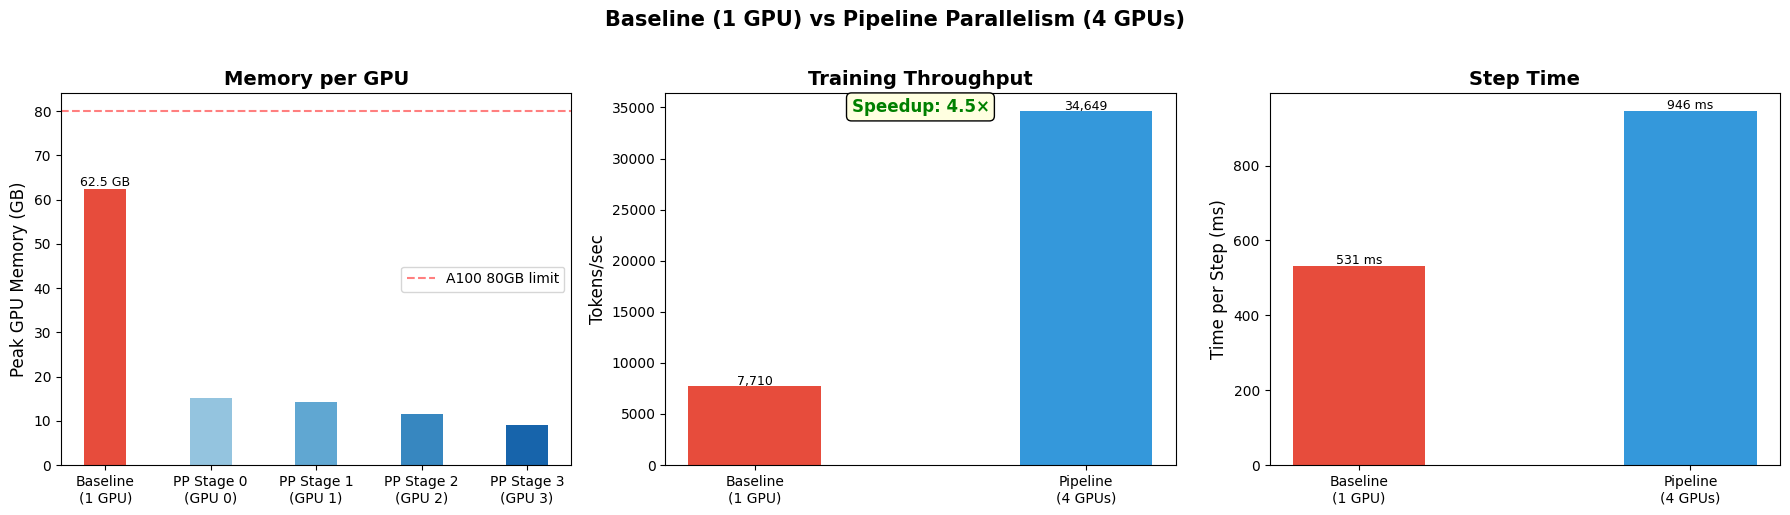


Memory reduction: 76% (62.5 GB → 15.2 GB per GPU)
Throughput speedup: 4.49×


In [ ]:
# ── Chart 1: Memory Comparison (Baseline vs PP) ──────────────
if "baseline" in results and "pp4_m16" in results:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Memory
    ax = axes[0]
    baseline_mem = results["baseline"]["peak_gpu_memory_gb"]
    pp_mems = results["pp4_m16"]["peak_gpu_memory_gb"]

    bars = ax.bar(["Baseline\n(1 GPU)"], [baseline_mem], color="#e74c3c", width=0.4)
    ax.bar([f"PP Stage {i}\n(GPU {i})" for i in range(len(pp_mems))], pp_mems,
            color=plt.cm.Blues(np.linspace(0.4, 0.8, len(pp_mems))), width=0.4)
    ax.set_ylabel("Peak GPU Memory (GB)", fontsize=12)
    ax.set_title("Memory per GPU", fontsize=14, fontweight="bold")
    ax.axhline(y=80, color="red", linestyle="--", alpha=0.5, label="A100 80GB limit")
    ax.legend()
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{bar.get_height():.1f} GB", ha="center", fontsize=9)

    # Throughput
    ax = axes[1]
    names = ["Baseline\n(1 GPU)", "Pipeline\n(4 GPUs)"]
    throughputs = [
        results["baseline"]["throughput_tokens_per_sec"],
        results["pp4_m16"]["throughput_tokens_per_sec"],
    ]
    colors = ["#e74c3c", "#3498db"]
    bars = ax.bar(names, throughputs, color=colors, width=0.4)
    ax.set_ylabel("Tokens/sec", fontsize=12)
    ax.set_title("Training Throughput", fontsize=14, fontweight="bold")
    for bar, val in zip(bars, throughputs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f"{val:,.0f}", ha="center", fontsize=9)
    speedup = throughputs[1] / throughputs[0] if throughputs[0] > 0 else 0
    ax.text(0.5, 0.95, f"Speedup: {speedup:.1f}×", transform=ax.transAxes,
            ha="center", fontsize=12, fontweight="bold", color="green",
            bbox=dict(boxstyle="round", facecolor="lightyellow"))

    # Step time
    ax = axes[2]
    bars = ax.bar(names,
                   [results["baseline"]["avg_step_time_ms"],
                   results["pp4_m16"]["avg_step_time_ms"]],
                  color=colors, width=0.4)
    ax.set_ylabel("Time per Step (ms)", fontsize=12)
    ax.set_title("Step Time", fontsize=14, fontweight="bold")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{bar.get_height():.0f} ms", ha="center", fontsize=9)

    plt.suptitle("Baseline (1 GPU) vs Pipeline Parallelism (4 GPUs)",
                 fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("comparison_baseline_vs_pp.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Print summary
    mem_reduction = (1 - max(pp_mems) / baseline_mem) * 100
    print(f"\nMemory reduction: {mem_reduction:.0f}% "
          f"({baseline_mem:.1f} GB → {max(pp_mems):.1f} GB per GPU)")
    print(f"Throughput speedup: {speedup:.2f}×")
else:
    print("Need both 'baseline' and 'pp4_m16' results for comparison chart.")

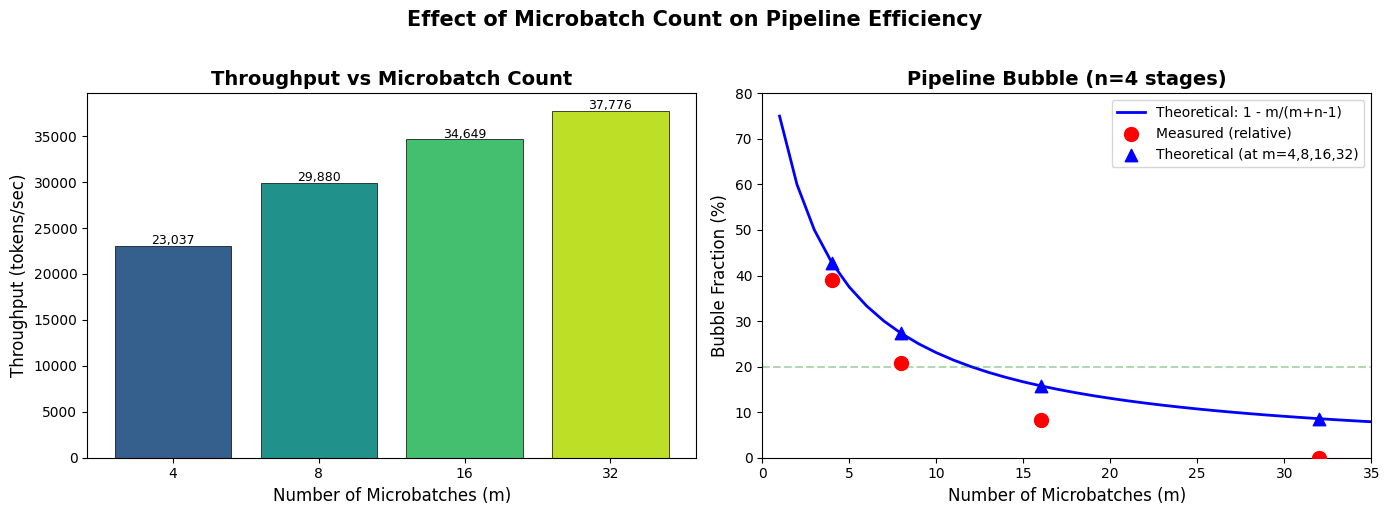


   m |  Bubble (theory) |     Throughput |    Step Time
-------------------------------------------------------
   4 |           42.9% |      23,037 t/s |     355.6 ms
   8 |           27.3% |      29,880 t/s |     548.3 ms
  16 |           15.8% |      34,649 t/s |     945.7 ms
  32 |            8.6% |      37,776 t/s |    1734.9 ms


In [ ]:
# ── Chart 2: Microbatch Scaling (Bubble Fraction Effect) ─────
m_values = [4, 8, 16, 32]
n = 4  # pipeline stages

measured_throughputs = []
theoretical_bubbles = []

for m in m_values:
    key = f"pp4_m{m}"
    theoretical_bubbles.append(1 - m / (m + n - 1))
    if key in results:
        measured_throughputs.append(results[key]["throughput_tokens_per_sec"])
    else:
        measured_throughputs.append(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Throughput vs microbatches
ax1.bar([str(m) for m in m_values], measured_throughputs,
        color=plt.cm.viridis(np.linspace(0.3, 0.9, len(m_values))),
        edgecolor="black", linewidth=0.5)
ax1.set_xlabel("Number of Microbatches (m)", fontsize=12)
ax1.set_ylabel("Throughput (tokens/sec)", fontsize=12)
ax1.set_title("Throughput vs Microbatch Count", fontsize=14, fontweight="bold")
for i, (m, tp) in enumerate(zip(m_values, measured_throughputs)):
    if tp > 0:
        ax1.text(i, tp + 200, f"{tp:,.0f}", ha="center", fontsize=9)

# Bubble fraction: theoretical vs measured
theoretical_line = [1 - m / (m + n - 1) for m in range(1, 40)]
ax2.plot(range(1, 40), [b * 100 for b in theoretical_line],
          'b-', linewidth=2, label="Theoretical: 1 - m/(m+n-1)")

if measured_throughputs and max(measured_throughputs) > 0:
    max_tp = max(measured_throughputs)
    measured_bubbles = [(1 - tp/max_tp) * 100 if tp > 0 else None for tp in measured_throughputs]
    valid = [(m, b) for m, b in zip(m_values, measured_bubbles) if b is not None]
    if valid:
        ax2.scatter([v[0] for v in valid], [v[1] for v in valid],
                    color="red", s=100, zorder=5, label="Measured (relative)")

ax2.scatter(m_values, [b * 100 for b in theoretical_bubbles],
            color="blue", s=80, zorder=5, marker="^", label="Theoretical (at m=4,8,16,32)")
ax2.set_xlabel("Number of Microbatches (m)", fontsize=12)
ax2.set_ylabel("Bubble Fraction (%)", fontsize=12)
ax2.set_title(f"Pipeline Bubble (n={n} stages)", fontsize=14, fontweight="bold")
ax2.legend(fontsize=10)
ax2.set_xlim(0, 35)
ax2.set_ylim(0, 80)
ax2.axhline(y=20, color="green", linestyle="--", alpha=0.3, label="20% target")

plt.suptitle("Effect of Microbatch Count on Pipeline Efficiency",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("microbatch_scaling.png", dpi=150, bbox_inches="tight")
plt.show()

# Print table
print(f"\n{'m':>4} | {'Bubble (theory)':>16} | {'Throughput':>14} | {'Step Time':>12}")
print("-" * 55)
for m in m_values:
    key = f"pp4_m{m}"
    bubble = 1 - m / (m + n - 1)
    if key in results:
        tp = results[key]["throughput_tokens_per_sec"]
        st = results[key]["avg_step_time_ms"]
        print(f"{m:>4} | {bubble:>15.1%} | {tp:>11,.0f} t/s | {st:>9.1f} ms")
    else:
        print(f"{m:>4} | {bubble:>15.1%} | {'N/A':>14} | {'N/A':>12}")

## 6. Key Takeaways

### What We Demonstrated

1. **Memory Reduction**: Pipeline parallelism splits the model across GPUs. Each GPU holds ~1/n of the parameters, optimizer states, and gradients. This is the primary reason PP exists — it enables training models that **don't fit on a single GPU**.

2. **Throughput Scaling**: With enough microbatches (m >> n), the pipeline bubble becomes small and throughput approaches linear scaling. The 1F1B schedule used by DeepSpeed keeps peak activation memory proportional to n (pipeline depth), not m.

3. **Microbatch Sweet Spot**:
   - Too few microbatches (m ≈ n) → large bubble → low GPU utilization
   - Too many microbatches (m >> n) → small bubble but each microbatch is tiny → kernel launch overhead
   - **Rule of thumb**: m ≥ 4n for < 20% bubble

### When to Use Pipeline Parallelism

| Scenario | Recommendation |
|----------|---------------|
| Model fits on 1 GPU | Use Data Parallelism (simpler, no bubble) |
| Model doesn't fit on 1 GPU | Use Pipeline Parallelism to split across GPUs |
| Very large model + many GPUs | Combine PP + DP + TP (3D parallelism) |
| Inter-node training | PP is ideal (only point-to-point comms between neighbors) |

### DeepSpeed vs From-Scratch

| | From-Scratch (our previous notebook) | DeepSpeed |
|---|---|---|
| **Schedule** | Manual instruction sequences | Automatic 1F1B |
| **Communication** | Manual Send/Recv | Handled internally |
| **Partitioning** | Manual layer assignment | Automatic by parameter count |
| **Activation checkpointing** | Not implemented | One flag to enable |
| **Mixed precision** | Manual AMP | Built-in FP16/BF16 |
| **Lines of code** | ~500 | ~50 |

**Takeaway**: Use DeepSpeed (or Megatron-LM) in production. Build from scratch to **understand** what's happening under the hood.